In [50]:
# Blessing Anoroh
# Final Project
# DATA 620 - Web Analytics
# May 17, 2026

**Introduction:**

The Enron Email Dataset provides a real-world example of organizational communication within a large company. This project combines network analysis and text processing techniques to explore how employees communicated through email and to identify influential individuals, communication groups, and common discussion themes within the organization.

Using sender and receiver information, a communication network was constructed where employees represent nodes and email exchanges represent connections. The project analyzes measures such as degree centrality, betweenness centrality, connected components, and community detection to better understand communication structure and influence within the network.

In addition, text processing techniques such as word frequency analysis and topic modeling with Latent Dirichlet Allocation (LDA) were used to examine the major themes discussed throughout the emails, including business operations, energy markets, workplace communication, and information exchange.

The goal of this project is to better understand both the structure of communication within Enron and the topics that dominated employee interactions. By combining network analysis with text processing, the project provides insight into how employees communicated and what themes appeared most frequently throughout the organization.


**Research Question:**

Who were the most influential individuals within the Enron email network, and what communication themes appeared most frequently throughout the organization?


In [51]:
# Imports

import pandas as pd
import numpy as np
import email
import re
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from networkx.algorithms.community import greedy_modularity_communities


In [52]:
# Load Dataset from Kaggle

!pip install kaggle -q

import os
import zipfile
import pandas as pd

os.makedirs('/root/.kaggle', exist_ok=True)


!kaggle datasets download -d wcukierski/enron-email-dataset

with zipfile.ZipFile("enron-email-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("enron_data")

df = pd.read_csv("enron_data/emails.csv")

print(df.shape)
df.head()

Dataset URL: https://www.kaggle.com/datasets/wcukierski/enron-email-dataset
License(s): copyright-authors
enron-email-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
(517401, 2)


,file,message
0,allen-p/_sent_mail/1.,Message-ID: <18782981.1075855378110.JavaMail.e...
1,allen-p/_sent_mail/10.,Message-ID: <15464986.1075855378456.JavaMail.e...
2,allen-p/_sent_mail/100.,Message-ID: <24216240.1075855687451.JavaMail.e...
3,allen-p/_sent_mail/1000.,Message-ID: <13505866.1075863688222.JavaMail.e...
4,allen-p/_sent_mail/1001.,Message-ID: <30922949.1075863688243.JavaMail.e...


In [53]:
def parse_email(message):
    msg = email.message_from_string(message)

    sender = msg.get("From")
    receiver = msg.get("To")
    subject = msg.get("Subject")
    date = msg.get("Date")
    body = msg.get_payload()

    return sender, receiver, subject, date, body


df[["sender", "receiver", "subject", "date", "body"]] = df["message"].apply(
    lambda x: pd.Series(parse_email(x))
)

df.head(2)


,file,message,sender,receiver,subject,date,body
0,allen-p/_sent_mail/1.,Message-ID: <18782981.1075855378110.JavaMail.e...,phillip.allen@enron.com,tim.belden@enron.com,,"Mon, 14 May 2001 16:39:00 -0700 (PDT)",Here is our forecast\n\n
1,allen-p/_sent_mail/10.,Message-ID: <15464986.1075855378456.JavaMail.e...,phillip.allen@enron.com,john.lavorato@enron.com,Re:,"Fri, 4 May 2001 13:51:00 -0700 (PDT)",Traveling to have a business meeting takes the...


In [54]:
# Clean Sender and Receiver Data

df = df.dropna(subset=["sender", "receiver"])

def clean_email_address(x):
    if pd.isna(x):
        return None

    x = str(x).lower().strip()
    x = re.sub(r"\s+", "", x)

    return x


def split_recipients(x):
    if pd.isna(x):
        return []

    x = str(x).lower()
    x = re.split(r",|\n|\t", x)

    x = [clean_email_address(i) for i in x if "@" in i]

    return x


df["sender"] = df["sender"].apply(clean_email_address)
df["receiver_list"] = df["receiver"].apply(split_recipients)

df = df[df["receiver_list"].apply(len) > 0]

print(df[["sender", "receiver_list"]].head())



                    sender              receiver_list
0  phillip.allen@enron.com     [tim.belden@enron.com]
1  phillip.allen@enron.com  [john.lavorato@enron.com]
2  phillip.allen@enron.com   [leah.arsdall@enron.com]
3  phillip.allen@enron.com    [randall.gay@enron.com]
4  phillip.allen@enron.com     [greg.piper@enron.com]


In [55]:
# Reducing the Dataset Size
# The dataset is large, so a sample is used.

df_sample = df.sample(n=10000, random_state=42)
print(df_sample.shape)

# The sampled dataset contains 10,000 email records
# and 8 variables used for the analysis.


(10000, 8)


In [56]:
# Constructing the Email Network

# In this network:
# - Nodes represent employee email addresses
# - Edges represent email communication between employees
# - Edge weights represent repeated communication frequency


G = nx.DiGraph()

for _, row in df_sample.iterrows():

    sender = row["sender"]
    receivers = row["receiver_list"]

    for receiver in receivers:

        if sender != receiver:

            if G.has_edge(sender, receiver):
                G[sender][receiver]["weight"] += 1

            else:
                G.add_edge(sender, receiver, weight=1)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())


Number of nodes: 13544
Number of edges: 35727


The constructed network contains 13,544 nodes and 35,727 edges, showing a large and highly connected communication network. The results suggest that employees maintained multiple communication relationships across the organization rather than isolated interactions.


In [57]:
# Basic Network Statistics


density = nx.density(G)
avg_degree = sum(dict(G.degree()).values()) / G.number_of_nodes()

print("Network Density:", density)
print("Average Degree:", avg_degree)

G_undirected = G.to_undirected()

num_components = nx.number_connected_components(G_undirected)
largest_component_size = len(max(nx.connected_components(G_undirected), key=len))

print("Number of connected components:", num_components)
print("Largest component size:", largest_component_size)


Network Density: 0.00019477567873656915
Average Degree: 5.275694034258712
Number of connected components: 191
Largest component size: 12788


The low network density shows that employees communicated with only a small portion of the organization rather than with everyone in the network. The average degree of about 5.28 suggests that employees maintained several communication connections on average. Although the network contained 191 smaller communication groups, the largest connected component included 12,788 nodes, showing that most employees were still part of one large communication structure.

In [58]:
# Centrality Analysis

# Centrality measures help identify influential individuals
# within the communication network.

degree_centrality = nx.degree_centrality(G)
in_degree_centrality = nx.in_degree_centrality(G)
out_degree_centrality = nx.out_degree_centrality(G)

# Approximate betweenness is used because the network is large.
betweenness_centrality = nx.betweenness_centrality(
    G,
    k=100,
    seed=42
)

centrality_df = pd.DataFrame({
    "person": list(G.nodes()),
    "degree_centrality": [degree_centrality[n] for n in G.nodes()],
    "in_degree_centrality": [in_degree_centrality[n] for n in G.nodes()],
    "out_degree_centrality": [out_degree_centrality[n] for n in G.nodes()],
    "betweenness_centrality": [betweenness_centrality[n] for n in G.nodes()]
})

top_degree = centrality_df.sort_values(
    "degree_centrality",
    ascending=False
).head(10)

top_betweenness = centrality_df.sort_values(
    "betweenness_centrality",
    ascending=False
).head(10)

print("Top Individuals by Degree Centrality")
print(top_degree)

print("Top Individuals by Betweenness Centrality")
print(top_betweenness)



Top Individuals by Degree Centrality
                            person  degree_centrality  in_degree_centrality  \
6451  jacqueline.coleman@enron.com           0.039799              0.000000   
333            mary.hain@enron.com           0.037732              0.002289   
3129         tom.delaney@enron.com           0.031234              0.000443   
95     veronica.espinoza@enron.com           0.030200              0.001034   
202        jeff.dasovich@enron.com           0.028428              0.009673   
3872        julie.clyatt@enron.com           0.027985              0.000148   
9755    technology.enron@enron.com           0.025770              0.000000   
120           tana.jones@enron.com           0.025031              0.009082   
1944       billy.lemmons@enron.com           0.022742              0.000443   
4250     andrea.richards@enron.com           0.022669              0.000148   

      out_degree_centrality  betweenness_centrality  
6451               0.039799            

The centrality results identify the most influential employees in the email network. Degree centrality shows who had the most direct communication connections, while betweenness centrality shows who served as bridges between different communication groups. These results help answer the research question by identifying individuals who played major roles in Enron’s communication flow.

The centrality results identified several highly influential individuals within the Enron communication network. Employees such as jacqueline.coleman@enron.com at 0.039, mary.hain@enron.com at 0.037, and tom.delaney@enron.com at 0.031 showed the highest degree centrality values, indicating that they maintained many direct communication connections and played active roles in organizational communication.


Employees such as tana.jones@enron.com at 0.008, mark.taylor@enron.com at 0.008, and jeff.dasovich@enron.com at 0.007 showed relatively high betweenness centrality values, suggesting that they acted as important bridge-like individuals connecting different communication groups and helping information flow across the network.



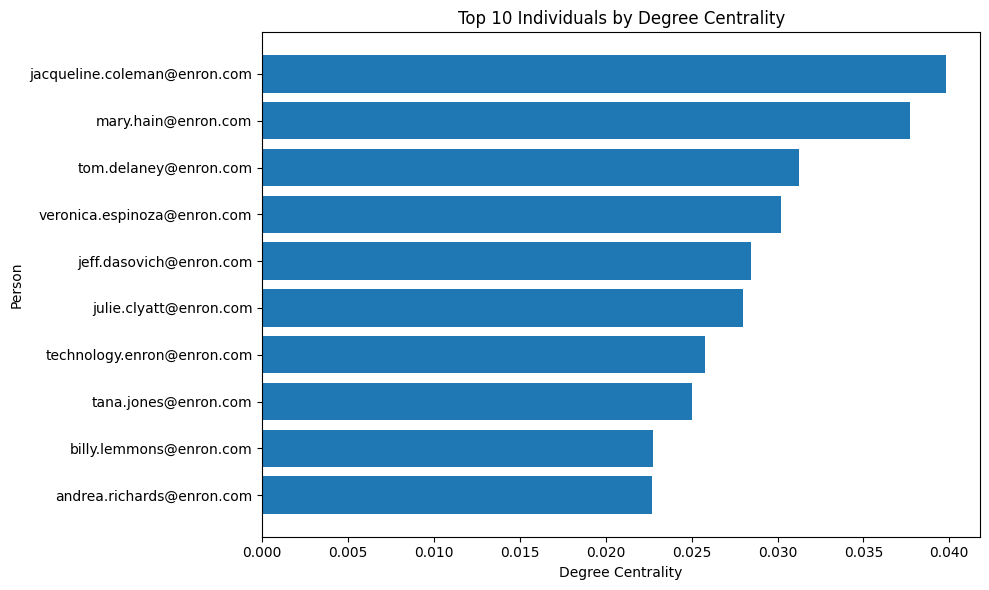

In [59]:
# Top 10 Degree Centrality Graph

plt.figure(figsize=(10, 6))
plt.barh(top_degree["person"], top_degree["degree_centrality"])
plt.xlabel("Degree Centrality")
plt.ylabel("Person")
plt.title("Top 10 Individuals by Degree Centrality")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


The visualization shows a noticeable difference in communication activity across employees, with a smaller number of individuals maintaining much higher direct connectivity than the rest of the network.

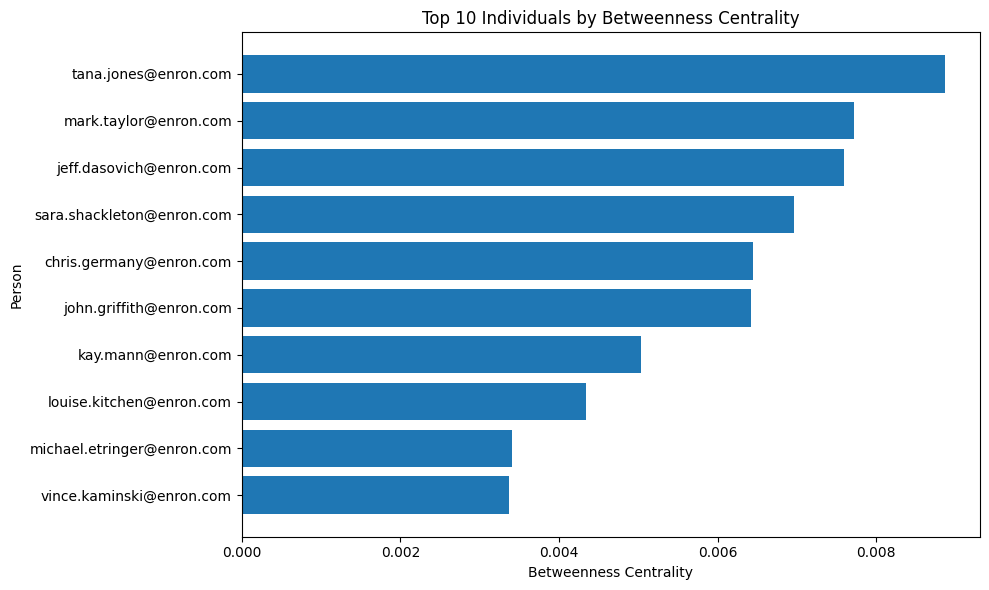

In [60]:
# Top 10 Betweenness Centrality Graph

plt.figure(figsize=(10, 6))
plt.barh(top_betweenness["person"], top_betweenness["betweenness_centrality"])
plt.xlabel("Betweenness Centrality")
plt.ylabel("Person")
plt.title("Top 10 Individuals by Betweenness Centrality")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


The visualization highlights variation in employees’ structural importance within the network, showing that some individuals occupied more central positions in connecting communication pathways across groups.

In [61]:
# Community Detection

# This is used to identify clusters of employees
# who communicate more frequently with one another.

communities = greedy_modularity_communities(
    G_undirected
)

print("Number of communities:", len(communities))

community_data = []

for i, community in enumerate(communities):

    for person in community:

        community_data.append({

            "person": person,
            "community": i,
            "community_size": len(community)

        })

community_df = pd.DataFrame(community_data)

centrality_community_df = centrality_df.merge(
    community_df,
    on="person",
    how="left"
)

print(centrality_community_df.head())

Number of communities: 288
                     person  degree_centrality  in_degree_centrality  \
0           mjones7@txu.com           0.001698              0.000222   
1           cstone1@txu.com           0.000738              0.000369   
2           ggreen2@txu.com           0.000738              0.000222   
3  daren.j.farmer@enron.com           0.000591              0.000591   
4    gary.a.hanks@enron.com           0.000295              0.000295   

   out_degree_centrality  betweenness_centrality  community  community_size  
0               0.001477                0.000000         33              51  
1               0.000369                0.000037         33              51  
2               0.000517                0.000000         33              51  
3               0.000000                0.000000         33              51  
4               0.000000                0.000000         33              51  


The community detection analysis identified 288 communication groups within the network, suggesting that employees communicated within smaller clusters rather than one completely unified structure. Several highly influential individuals were also part of the network’s largest communities.

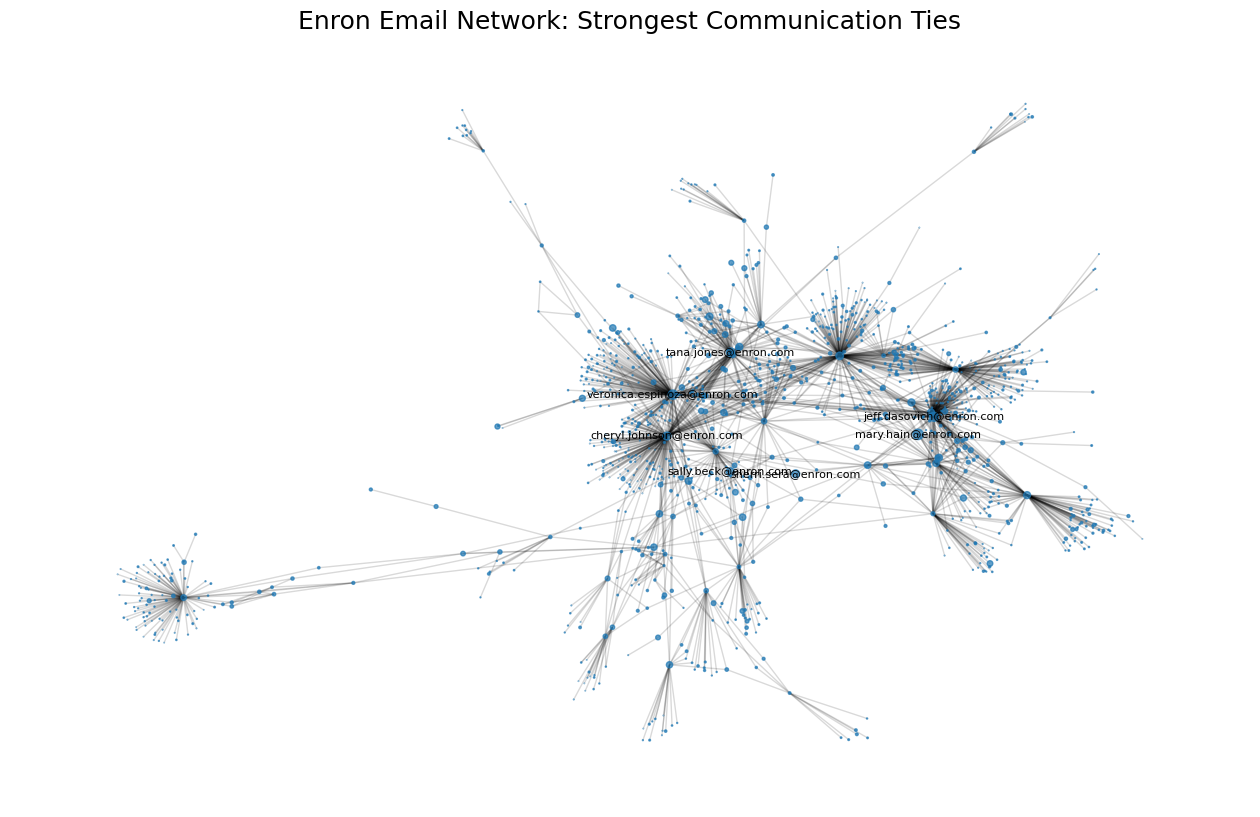

Nodes shown in visual: 1247
Edges shown in visual: 1881


In [62]:
# Network Visualization
# Only strong communication ties shown

strong_edges = [

    (u, v)
    for u, v, w in G.edges(data="weight")
    if w >= 5
]

G_strong = G.edge_subgraph(strong_edges).copy()
G_strong_undirected = G_strong.to_undirected()
largest_component = max(
    nx.connected_components(G_strong_undirected),
    key=len
)

G_viz = G_strong_undirected.subgraph(
    largest_component
)

plt.figure(figsize=(16, 10))

pos = nx.spring_layout(
    G_viz,
    seed=42,
    k=0.6,
    iterations=100
)

node_sizes = [
    1500 * degree_centrality.get(node, 0.01)
    for node in G_viz.nodes()
]

nx.draw_networkx_nodes(
    G_viz,
    pos,
    node_size=node_sizes,
    alpha=0.7
)

nx.draw_networkx_edges(
    G_viz,
    pos,
    alpha=0.15
)

top_nodes = sorted(
    degree_centrality,
    key=degree_centrality.get,
    reverse=True
)[:15]

# Only the top 15 most connected individuals are labeled.

labels = {
    node: node
    for node in top_nodes
    if node in G_viz.nodes()
}

nx.draw_networkx_labels(
    G_viz,
    pos,
    labels=labels,
    font_size=8
)

plt.title(
    "Enron Email Network: Strongest Communication Ties",
    fontsize=18
)

plt.axis("off")
plt.show()

print("Nodes shown in visual:", G_viz.number_of_nodes())
print("Edges shown in visual:", G_viz.number_of_edges())

The network visualization reveals a hub-and-spoke structure within the Enron organization. Several highly connected individuals appear near the center of the network, while smaller clusters branch outward from these central hubs. Bridge-like connections between groups suggest that certain employees played important roles in maintaining information flow across the organization.

The visualization contains 1,247 nodes and 1,881 edges representing the strongest email relationships within the network. Filtering weaker ties improved readability while still preserving the network’s major structural patterns.

In [63]:
# Text Cleaning and Preprocessing

# I Cleaned email text by removing unnecessary formatting, punctuation, links, and email addresses.

def clean_text(text):

    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


df_sample["clean_body"] = df_sample["body"].apply(
    clean_text
)

df_text = df_sample[
    df_sample["clean_body"].str.len() > 20
]

print(df_text[["sender", "clean_body"]].head())


                          sender  \
103048           mjones7@txu.com   
471612      kate.symes@enron.com   
240410     steven.kean@enron.com   
378302  louis.iaconetti@csfb.com   
263845   anthony.dayao@enron.com   

                                               clean_body  
103048  december teco tap enron hpl gas daily ls hpl l...  
471612  i ve changed the term to and i m going to make...  
240410  i ll send it back on tuesday jose pm to steven...  
378302  i spoke to aquila again today they are plannin...  
263845  everyone i know everyone has been awaiting thi...  


The cleaned email text removes unnecessary formatting and characters from the original emails, making the text more suitable for word frequency analysis and topic modeling.

           word  count
6         enron   9892
25      subject   8823
20           pm   7301
1            cc   6101
18          new   4858
16      message   4735
14         mail   4721
21        power   4680
5        energy   4343
23         sent   4186
27       thanks   4021
28         time   3912
22         said   3868
26           td   3850
11         know   3767
9           gas   3702
10  information   3253
19     original   3194
7          font   3092
15       market   3089
0    california   2984
3       company   2958
8     forwarded   2923
17         need   2920
24        state   2805
4           day   2763
13         like   2753
29         week   2714
12          let   2713
2           com   2502


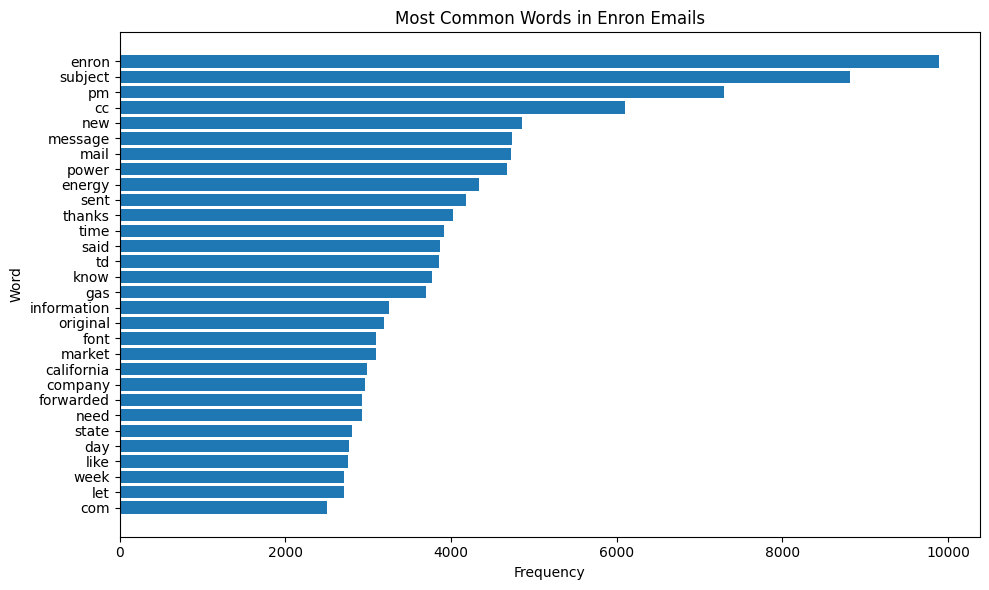

In [64]:
# Word Frequency Analysis

# Count the most common words appearing
# throughout the Enron email dataset.

vectorizer = CountVectorizer(
    stop_words="english",
    max_features=30
)

word_matrix = vectorizer.fit_transform(
    df_text["clean_body"]
)

word_counts = np.asarray(
    word_matrix.sum(axis=0)
).flatten()

words = vectorizer.get_feature_names_out()

word_freq = pd.DataFrame({

    "word": words,
    "count": word_counts

}).sort_values(
    "count",
    ascending=False
)

print(word_freq)

plt.figure(figsize=(10, 6))

plt.barh(
    word_freq["word"],
    word_freq["count"]
)

plt.xlabel("Frequency")
plt.ylabel("Word")

plt.title(
    "Most Common Words in Enron Emails"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()



The word frequency results show that terms such as “enron,” “power,” “energy,” “gas,” and “market” appeared frequently throughout the email communications, suggesting that much of the discussion focused on business operations and the energy industry. The visualization also highlights common internal communication terms such as “message,” “mail,” “sent,” and “forwarded,” reflecting the corporate and email-based nature of the dataset.


In [65]:
# Topic Modeling with LDA (Latent Dirichlet Allocation)

# LDA topic modeling is used to identify recurring
# discussion themes within the emails.

topic_vectorizer = CountVectorizer(

    stop_words="english",
    max_df=0.90,
    min_df=20,
    max_features=1000
)

topic_matrix = topic_vectorizer.fit_transform(
    df_text["clean_body"]
)

lda = LatentDirichletAllocation(
    n_components=5,
    random_state=42,
    learning_method="batch"
)

lda.fit(topic_matrix)

topic_words = topic_vectorizer.get_feature_names_out()


def display_topics(
    model,
    feature_names,
    num_words=10
):

    topics = []

    for topic_idx, topic in enumerate(model.components_):

        top_indices = topic.argsort()[-num_words:][::-1]

        top_terms = [
            feature_names[i]
            for i in top_indices
        ]

        topics.append({

            "topic": topic_idx + 1,

            "top_words": ", ".join(top_terms)

        })

    return pd.DataFrame(topics)


topics_df = display_topics(
    lda,
    topic_words,
    10
)

print(topics_df)




   topic                                          top_words
0      1  subject, pm, cc, enron, message, sent, thanks,...
1      2  td, font, size, pt, align, tr, nbsp, br, dec, ...
2      3  power, energy, said, market, california, state...
3      4  time, week, day, just, like, know, good, think...
4      5  enron, data, mail, com, date, information, dat...


The topic modeling results identified several recurring themes within the Enron emails, including business operations, energy markets, workplace communication, technical formatting, and information exchange. These topics help provide insight into the major subjects discussed throughout the organization and complement the network analysis by showing what employees were communicating about.

dominant_topic
1    5439
2      75
3    1195
4    1899
5    1208
Name: count, dtype: int64


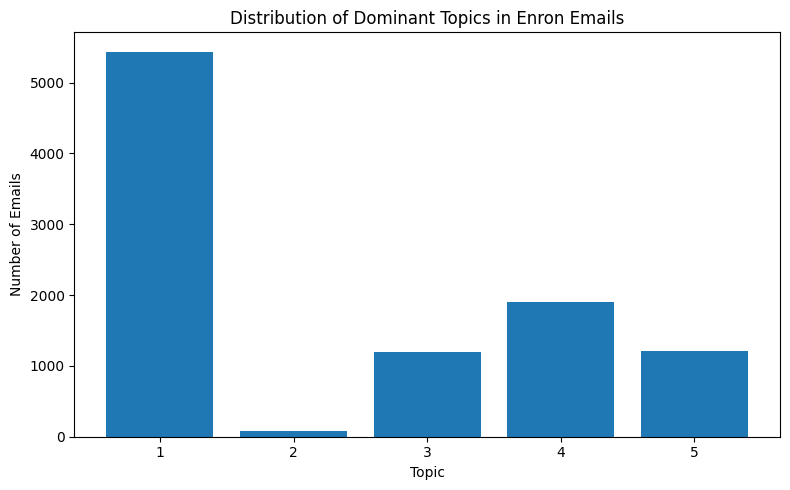

In [66]:
# Topic Distribution


# Analyze how frequently each topic appears
# throughout the email dataset.
topic_distribution = lda.transform(
    topic_matrix
)

df_text = df_text.copy()

df_text["dominant_topic"] = (
    topic_distribution.argmax(axis=1) + 1
)

topic_counts = df_text[
    "dominant_topic"
].value_counts().sort_index()

print(topic_counts)

plt.figure(figsize=(8, 5))

plt.bar(
    topic_counts.index.astype(str),
    topic_counts.values
)

plt.xlabel("Topic")

plt.ylabel("Number of Emails")

plt.title(
    "Distribution of Dominant Topics in Enron Emails"
)

plt.tight_layout()

plt.show()


The topic distribution graph shows that Topic 1 appeared much more frequently than the other topics in the dataset, suggesting that much of the communication focused on general email and messaging activity. Topics related to business operations, workplace discussion, and information exchange appeared less often but still represented important themes throughout the Enron emails.

**Conclusion :**

Overall, the analysis showed that communication within the Enron organization was centered around a smaller number of highly influential individuals who maintained important communication connections across the network. The network also contained multiple communication communities, suggesting that employees communicated more frequently within smaller groups rather than evenly across the entire organization.

The text analysis further revealed recurring themes related to business operations, energy markets, workplace communication, and information exchange. By combining network analysis with text processing, the analysis provided a broader understanding of both the structure of communication within Enron and the major topics discussed throughout the organization.

